## Convolutional neural network using physicochemical descriptors to predict log binding affinity

### Load the data:

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, ParameterGrid
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, r2_score

Xtrain = pd.read_csv('/dcs/22/u2243582/cs310/feature_extraction/Xtrainfeatnew.csv', index_col=0)
Xtest = pd.read_csv('/dcs/22/u2243582/cs310/feature_extraction/Xtestfeatnew.csv', index_col=0)
X = pd.concat([Xtrain, Xtest])
X = X.sort_values(by='Index_original')
X_csv = pd.read_csv('/dcs/22/u2243582/cs310/feature_extraction/refined-set-csv.csv')
data = X.join(X_csv['PDB_Code'])
data = data.join(X_csv['Log_binding'])
display(data)

,MolecularWeight,Aromaticity,InstabilityIndex,Gravy,MoreauBrotoAuto_Hydrophobicity1,MoreauBrotoAuto_Hydrophobicity2,MoreauBrotoAuto_Hydrophobicity3,MoreauBrotoAuto_Hydrophobicity4,MoreauBrotoAuto_Hydrophobicity5,MoreauBrotoAuto_Hydrophobicity6,...,MolLogP,NumHAcceptors,NumHDonors,NumRotatableBonds,RingCount,LabuteASA,Kappa1,BalabanJ,PDB_Code,Log_binding
Index_original,,,,,,,,,,,,,,,,,,,,,
0,28890.2555,0.105058,20.111284,-0.577432,-0.069,-0.066,-0.061,-0.062,-0.063,-0.059,...,1.16380,3,2,0,2,85.115803,9.291447,2.755753,6ugp,6.16
1,17325.4941,0.114094,35.021477,-0.654362,0.093,0.097,0.105,0.105,0.107,0.088,...,-1.52050,9,4,3,3,113.421074,13.185962,2.031041,4rdn,5.92
2,74371.0384,0.059163,44.232179,0.015729,-0.010,-0.010,-0.010,-0.010,-0.011,-0.011,...,-2.28750,14,3,6,3,151.244978,20.269054,1.748652,4mo4,4.22
3,13535.4695,0.042017,37.857983,-0.388235,-0.035,-0.046,-0.034,-0.024,-0.014,-0.020,...,4.58340,1,1,2,3,100.720024,9.911594,2.063095,3s0b,6.49
4,11850.3812,0.141509,37.638679,-0.111321,0.005,0.004,0.004,0.001,-0.011,-0.012,...,0.32790,4,2,3,2,103.313061,12.096595,1.791206,6r1d,5.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5244,129734.0766,0.075758,40.627189,-0.085606,-0.013,-0.012,-0.010,-0.010,-0.010,-0.011,...,2.19470,4,2,3,4,153.499718,17.045406,1.809687,6p3t,7.32
5245,23305.0899,0.076233,22.296861,-0.059641,0.047,0.043,0.043,0.044,0.051,0.046,...,-1.95550,2,2,2,1,76.357033,9.964175,3.080437,1tx7,4.60
5246,35893.3613,0.033537,22.086890,-0.063720,0.019,0.019,0.019,0.019,0.019,0.019,...,-2.57180,15,3,6,3,149.085055,19.947729,1.757685,3ta1,3.25


In [11]:
X = X.values
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)
X = torch.tensor(X, dtype=torch.float32)  # Features (285 columns)
y = torch.tensor(data['Log_binding'].values, dtype=torch.float32)   # Target

X = X.unsqueeze(1)  # Add channel dimension → [batch, 1, 285]

In [12]:
# Detect GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Define the CNN model:

In [13]:
class CNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_filters, kernel_size, dropout_rate):
        super(CNNModel, self).__init__()

        self.hidden_dim = hidden_dim  

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=num_filters, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(num_filters)

        self.conv2 = nn.Conv1d(in_channels=num_filters, out_channels=num_filters * 2, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(num_filters * 2)

        self.conv3 = nn.Conv1d(in_channels=num_filters * 2, out_channels=num_filters * 4, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn3 = nn.BatchNorm1d(num_filters * 4)

        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)  # Dropout layer

        self.flatten_dim = self._get_flatten_dim(input_dim, num_filters, kernel_size)
        
        # Fully connected layers
        self.fc1 = nn.Linear(self.flatten_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)  # New fully connected layer
        self.fc3 = nn.Linear(hidden_dim // 2, 1)

    def _get_flatten_dim(self, input_dim, num_filters, kernel_size):
        # Helper function to compute the output size dynamically
        
        sample_input = torch.randn(1, 1, input_dim)  
        
        x = self.pool(self.relu(self.bn1(self.conv1(sample_input))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))

        return x.view(1, -1).size(1)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        x = x.view(x.size(0), -1)  # Flatten tensor to [batch_size, flattened_dim]

        x = self.relu(self.fc1(x))
        x = self.dropout(x) 

        x = self.relu(self.fc2(x))
        # x = self.dropout(x) 

        x = self.fc3(x)

        return x.squeeze()


In [14]:
def train(model, train_loader, val_loader, criterion, optimizer, epochs=50, patience=10):
    
    model.to(device)
    best_loss = float("inf")
    patience_counter = 0
    epoch_losses = []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        epoch_losses.append(avg_train_loss)

        # ---- Validation Step ----
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                val_loss += criterion(y_pred, y_batch).item()

        avg_val_loss = val_loss / len(val_loader)
        
        # ---- Early Stopping Check ----
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping after {epoch+1} epochs")
                break  

    return epoch_losses

## Run the nested CV:

In [15]:
param_grid = {
    "hidden_dim": [64, 128, 256, 512], # Neurons per hidden layer, more = more complex representations
    "dropout_rate": [0.1, 0.2, 0.3],
    "learning_rate": [0.01, 0.005, 0.001, 0.0005], # Step size at each iteration moving toward minimum of loss function - during optimisation
    "num_filters": [16, 32, 64],
    "kernel_size": [3, 5, 7]
}

# ---- Outer Loop ----
outer_kf = KFold(n_splits=5, shuffle=True, random_state=1)
all_loss_curves = []

results = [] # Store results

for fold, (train_idx, test_idx) in enumerate(outer_kf.split(X)):
    print(f"Outer Fold {fold+1}/5")
    
    random_params = [
    {key: random.choice(values) for key, values in param_grid.items()} 
    for _ in range(3)
    ]
    
    # print("random_params for this outer fold:", random_params)

    X_train_outer, X_test_outer = X[train_idx], X[test_idx]
    y_train_outer, y_test_outer = y[train_idx], y[test_idx]

    inner_kf = KFold(n_splits=3, shuffle=True, random_state=1)
    best_params = None
    best_val_loss = float("inf")
    
    # ---- Inner Loop: Hyperparameter Tuning ----
    for params in random_params:
        print("Using hyperparams", params)
        
        val_losses = []

        for train_inner_idx, val_idx in inner_kf.split(X_train_outer):
            X_train_inner, X_val = X_train_outer[train_inner_idx], X_train_outer[val_idx]
            y_train_inner, y_val = y_train_outer[train_inner_idx], y_train_outer[val_idx]

            train_loader = DataLoader(TensorDataset(X_train_inner, y_train_inner), batch_size=32, shuffle=True)
            val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

            model = CNNModel(input_dim=285, 
                hidden_dim=params["hidden_dim"],
                num_filters=params["num_filters"],
                kernel_size=params["kernel_size"],
                dropout_rate=params["dropout_rate"]).to(device)
            # criterion = nn.MSELoss()
            criterion = nn.L1Loss()
            optimizer = optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=0)

            epoch_losses = train(model, train_loader, val_loader, criterion, optimizer, epochs=50)
            val_losses.append(min(epoch_losses))

        mean_val_loss = np.mean(val_losses)

        if mean_val_loss < best_val_loss:
            best_val_loss = mean_val_loss
            best_params = params

    print(f"Best hyperparams for Fold {fold+1}: {best_params}")
    
    # ---- Train Final Model with Best Hyperparams ----
    train_loader = DataLoader(TensorDataset(X_train_outer, y_train_outer), batch_size=64, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_outer, y_test_outer), batch_size=64, shuffle=False)

    model = CNNModel(input_dim=285, 
                hidden_dim=best_params["hidden_dim"],
                num_filters=best_params["num_filters"],
                kernel_size=best_params["kernel_size"],
                dropout_rate=best_params["dropout_rate"]).to(device)
    # criterion = nn.MSELoss()
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=best_params["learning_rate"], weight_decay=0)

    epoch_losses = train(model, train_loader, test_loader, criterion, optimizer, epochs=50)
    all_loss_curves.append(epoch_losses)
    
    # ---- Evaluate Model ----
    model.eval()
    y_pred_list, y_true_list = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch).cpu().numpy()
            y_true = y_batch.cpu().numpy()

            y_pred_list.extend(y_pred)
            y_true_list.extend(y_true)

    pearson_corr, pearson_p = pearsonr(y_true_list, y_pred_list)
    spearman_corr, spearman_p = spearmanr(y_true_list, y_pred_list)
    mae = mean_absolute_error(y_true_list, y_pred_list)
    variance = np.var(np.array(y_true_list) - np.array(y_pred_list))
    r2 = r2_score(y_true_list, y_pred_list)

    results.append({"Fold": fold+1, "Pearson": pearson_corr, "Pearson p": pearson_p, "Spearman": spearman_corr, "Spearman p": spearman_p, "MAE": mae, "Variance": variance, "R2": r2})

Outer Fold 1/5
Using hyperparams {'hidden_dim': 128, 'dropout_rate': 0.1, 'learning_rate': 0.005, 'num_filters': 64, 'kernel_size': 7}
Early stopping after 43 epochs
Early stopping after 34 epochs
Early stopping after 31 epochs
Using hyperparams {'hidden_dim': 128, 'dropout_rate': 0.1, 'learning_rate': 0.005, 'num_filters': 32, 'kernel_size': 7}
Early stopping after 39 epochs
Early stopping after 37 epochs
Using hyperparams {'hidden_dim': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'num_filters': 16, 'kernel_size': 5}
Early stopping after 28 epochs
Early stopping after 28 epochs
Early stopping after 27 epochs
Best hyperparams for Fold 1: {'hidden_dim': 128, 'dropout_rate': 0.1, 'learning_rate': 0.005, 'num_filters': 32, 'kernel_size': 7}
Early stopping after 30 epochs
Outer Fold 2/5
Using hyperparams {'hidden_dim': 64, 'dropout_rate': 0.1, 'learning_rate': 0.01, 'num_filters': 16, 'kernel_size': 7}
Early stopping after 49 epochs
Early stopping after 17 epochs
Early stopping after

In [16]:
print(results)

[{'Fold': 1, 'Pearson': 0.7250252190605776, 'Pearson p': 9.19455316891038e-166, 'Spearman': 0.7071196630428307, 'Spearman p': 3.323624173438374e-154, 'MAE': 1.057643, 'Variance': 1.8778261, 'R2': 0.510468741168275}, {'Fold': 2, 'Pearson': 0.7198836062414138, 'Pearson p': 2.371325583758281e-162, 'Spearman': 0.7156676009298368, 'Spearman p': 1.304968323958765e-159, 'MAE': 1.0866772, 'Variance': 1.8543952, 'R2': 0.46954557538352326}, {'Fold': 3, 'Pearson': 0.7074543718951991, 'Pearson p': 2.0588246896009796e-154, 'Spearman': 0.6995550157506386, 'Spearman p': 1.3963591573715091e-149, 'MAE': 1.0593258, 'Variance': 1.8984497, 'R2': 0.4871705172779831}, {'Fold': 4, 'Pearson': 0.7119287734159768, 'Pearson p': 3.19545910304185e-157, 'Spearman': 0.6999313138183729, 'Spearman p': 8.288126542317292e-150, 'MAE': 1.1472684, 'Variance': 1.8615652, 'R2': 0.4455837453906888}, {'Fold': 5, 'Pearson': 0.7387412375030606, 'Pearson p': 4.3835277543922257e-175, 'Spearman': 0.7326986278531036, 'Spearman p': 7

In [17]:
# Nested CV Extract metrics
pearson_scores = [result['Pearson'] for result in results]
spearman_scores = [result['Spearman'] for result in results]
mae_scores = [result['MAE'] for result in results]
var_scores = [result['Variance'] for result in results]
r2_scores = [result['R2'] for result in results]
pearson_p_values = [result['Pearson p'] for result in results]
spearman_p_values = [result['Spearman p'] for result in results]

# Calculate means and standard deviations
pearson_mean = np.mean(pearson_scores)
pearson_std = np.std(pearson_scores)

spearman_mean = np.mean(spearman_scores)
spearman_std = np.std(spearman_scores)

mae_mean = np.mean(mae_scores)
mae_std = np.std(mae_scores)

var_mean = np.mean(var_scores)
var_std = np.std(var_scores)

r2_mean = np.mean(r2_scores)
r2_std = np.std(r2_scores)

pearson_p_mean = np.mean(pearson_p_values)
pearson_p_std = np.std(pearson_p_values)

spearman_p_mean = np.mean(spearman_p_values)
spearman_p_std = np.std(spearman_p_values)

# Print the results
print(f"Pearson Correlation: Mean = {pearson_mean}, Std = {pearson_std}, p-value Mean = {pearson_p_mean}, p-value Std = {pearson_p_std}")
print(f"Spearman Correlation: Mean = {spearman_mean}, Std = {spearman_std}, p-value Mean = {spearman_p_mean}, p-value Std = {spearman_p_std}")
print(f"MAE: Mean = {mae_mean}, Std = {mae_std}")
print(f"Variance: Mean = {var_mean}, Std = {var_std}")
print(f"R2: Mean = {r2_mean}, Std = {r2_std}")

Pearson Correlation: Mean = 0.7206066416232456, Std = 0.010928840469869612, p-value Mean = 4.124040344852944e-155, p-value Std = 8.232112578397736e-155
Spearman Correlation: Mean = 0.7109944442789565, Std = 0.012338373377185187, p-value Mean = 4.45041009595094e-150, p-value Std = 5.738365293683316e-150
MAE: Mean = 1.0756609439849854, Std = 0.04042418673634529
Variance: Mean = 1.8625166416168213, Std = 0.025964120402932167
R2: Mean = 0.487631199765283, Std = 0.02843369793398512


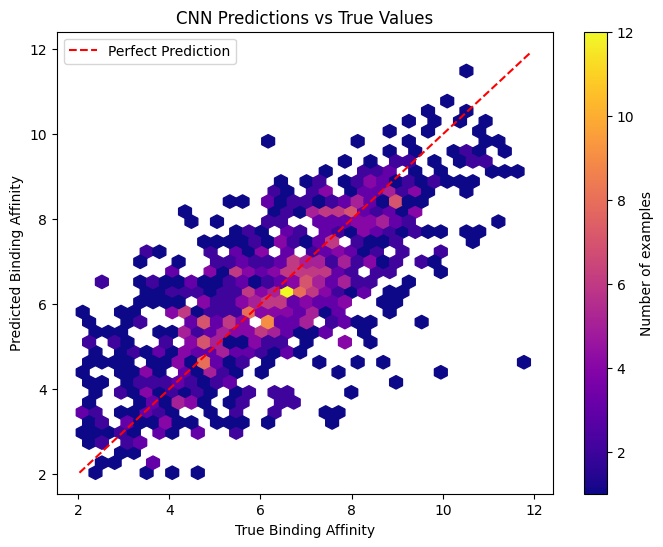

In [18]:
# Create hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_true_list, y_pred_list, gridsize=35, cmap='plasma', mincnt=1)

# Add a colorbar to indicate density
cb = plt.colorbar(hb)
cb.set_label('Number of examples')

# Add labels and title
plt.xlabel("True Binding Affinity")
plt.ylabel("Predicted Binding Affinity")
plt.title("CNN Predictions vs True Values")

# Add a diagonal line y = x to show the ideal prediction
min_val = min(min(y_true_list), min(y_pred_list))
max_val = max(max(y_true_list), max(y_pred_list))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add legend
plt.legend()

# Show the plot
plt.show()

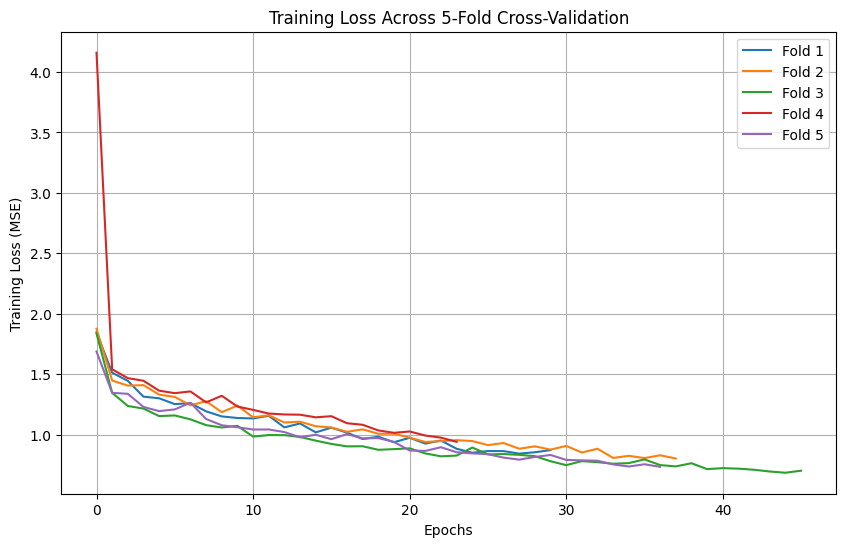

In [19]:
plt.figure(figsize=(10, 6))
for i, losses in enumerate(all_loss_curves):
    plt.plot(losses, label=f'Fold {i+1}')
plt.xlabel("Epochs")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss Across 5-Fold Cross-Validation")
plt.legend()
plt.grid(True)
plt.show()